<a href="https://colab.research.google.com/github/falknerdominik/.config/blob/master/participants_task_1_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab setup

Run Cell 2 before the task. It installs Chronos and finds bundled data automatically. When opened directly in Google Colab, it prompts you to select the included `data.zip`.


In [1]:
%pip -q install chronos-forecasting

from pathlib import Path
from zipfile import ZipFile

data_candidates = [
    Path("/content/gcolab/data"),
    Path("/content/data"),
    Path.cwd() / "data",
    Path.cwd() / "gcolab" / "data",
    Path("/content/drive/MyDrive/gcolab/data"),
]
if not any(path.exists() for path in data_candidates):
    try:
        from google.colab import files
    except ImportError as error:
        raise FileNotFoundError("Place data/ beside this notebook or run it in Google Colab.") from error
    uploaded = files.upload()
    archive_name = next((name for name in uploaded if name.endswith(".zip")), None)
    if archive_name is None:
        raise FileNotFoundError("Select the data.zip included with this workshop.")
    destination = Path("/content/gcolab")
    destination.mkdir(parents=True, exist_ok=True)
    with ZipFile(archive_name) as archive:
        archive.extractall(destination)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 2.8 MB/s eta 0:00:00


Saving data.zip to data.zip


# Task 1: Forecast PV surplus

Use past household data and the day-ahead irradiance forecast to predict one
day's PV surplus. The exercise is about choosing information that is known at
planning time.




## 1. Setup and configuration




In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from chronos import Chronos2Pipeline
from matplotlib import dates as mdates

INTERVAL_HOURS = 0.25
INTERVALS_PER_DAY = 96
HISTORICAL_DAYS = 60
EVALUATION_DAYS = 30
CONTEXT_INTERVALS = 28 * INTERVALS_PER_DAY
HORIZON = INTERVALS_PER_DAY
CHARGER_POWER_KW = 3.6
MAX_INPUT_KWH = CHARGER_POWER_KW * INTERVAL_HOURS
CHARGING_EFFICIENCY = 0.95
START_TIMESTAMP = pd.Timestamp("2026-01-05", tz="UTC")
HOLIDAY_DATES = pd.to_datetime(["2026-01-06", "2026-04-03", "2026-04-06"], utc=True)
DATA_PATH_CANDIDATES = [
    Path("/content/gcolab/data"),
    Path("/content/data"),
    Path.cwd() / "data",
    Path.cwd() / "gcolab" / "data",
    Path("/content/drive/MyDrive/gcolab/data"),
]
DATA_DIR = next((path for path in DATA_PATH_CANDIDATES if path.exists()), DATA_PATH_CANDIDATES[0])
HOUSEHOLD_PATH = DATA_DIR / "household.csv"
EV_PATH = DATA_DIR / "ev.csv"
FORECASTS_PATH = DATA_DIR / "forecasts.csv"
CHARGING_RESULTS_PATH = DATA_DIR / "charging_results.csv"
COVARIATE_COLUMNS = [
    "ghi_forecast_w_m2",
    "expected_load_kwh",
    "dow_mon",
    "dow_tue",
    "dow_wed",
    "dow_thu",
    "dow_fri",
    "dow_sat",
    "dow_sun",
    "is_holiday",
    "day_sin",
    "day_cos",
    "week_sin",
    "week_cos",
]
MODEL: Chronos2Pipeline | None = None
ACTUAL_COLOR = "0.15"
FORECAST_COLOR = "tab:blue"
BASELINE_COLOR = "0.45"
IMMEDIATE_COLOR = "0.45"
BROWSER_DAY = "2026-03-12"
SELECTED_DAY = "2026-03-08"
RUN_30_DAY_EVALUATION = False


def load_saved_data() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the persisted data created by the data-creation notebook.

    Returns:
        Household and EV data with UTC timestamps.

    Raises:
        FileNotFoundError: If the data-creation notebook has not been run.
    """
    if not HOUSEHOLD_PATH.exists() or not EV_PATH.exists():
        raise FileNotFoundError(
            "Run notebooks/01_create_workshop_data.py before this scenario and forecasting notebook."
        )
    household = pd.read_csv(HOUSEHOLD_PATH, parse_dates=["timestamp"])
    ev = pd.read_csv(EV_PATH, parse_dates=["timestamp", "departure_time"])
    household["timestamp"] = pd.to_datetime(household["timestamp"], utc=True)
    ev["timestamp"] = pd.to_datetime(ev["timestamp"], utc=True)
    ev["departure_time"] = pd.to_datetime(ev["departure_time"], utc=True)
    required_household_columns = {
        "timestamp",
        "scenario",
        "weather_type",
        "ghi_actual_w_m2",
        "ghi_forecast_w_m2",
        "pv_actual_kwh",
        "household_load_kwh",
        "pv_surplus_actual_kwh",
        "price_eur_per_kwh",
    }
    required_ev_columns = {
        "timestamp",
        "vehicle_id",
        "charging_possible",
        "departure_time",
        "daily_distance_km",
        "required_charge_kwh",
    }
    if not required_household_columns <= set(household) or not required_ev_columns <= set(ev):
        raise ValueError("Saved CSV files have an unexpected schema. Rerun notebooks/01_create_workshop_data.py.")
    return household, ev


def format_day_axis(axis: plt.Axes, day_start: pd.Timestamp, title: str) -> None:
    """Format a selected-day time axis with a 24-hour UTC clock.

    Args:
        axis: Bottom axis of a selected-day plot.
        day_start: UTC midnight at the start of the displayed day.
        title: Figure title containing the date exactly once.
    """
    axis.set_xlim(day_start, day_start + pd.Timedelta(days=1))
    axis.xaxis.set_major_locator(mdates.HourLocator(interval=2, tz="UTC"))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="UTC"))
    axis.set_xlabel("UTC time")
    axis.figure.suptitle(title)
    for plot_axis in axis.figure.axes:
        plot_axis.grid(axis="x", alpha=0.2)


def browse_saved_day(day: str, household: pd.DataFrame) -> pd.DataFrame:
    """Display realized weather, PV, load, and surplus for one saved day.

    Args:
        day: ISO date present in the saved household data.
        household: Household observations loaded from household.csv.

    Returns:
        The 96 saved interval rows displayed in the browser.

    Raises:
        ValueError: If the requested date is not present in household data.
    """
    day_start = pd.Timestamp(day, tz="UTC")
    day_rows = household.loc[household["timestamp"].dt.normalize() == day_start].copy()
    if len(day_rows) != INTERVALS_PER_DAY:
        raise ValueError(
            f"BROWSER_DAY must be from {household['timestamp'].min().date()} to {household['timestamp'].max().date()}."
        )

    daily_summary = day_rows.iloc[0][["scenario", "weather_type"]].to_frame().T
    daily_summary["date"] = day_start.date()
    daily_summary["pv_kwh"] = day_rows["pv_actual_kwh"].sum()
    daily_summary["load_kwh"] = day_rows["household_load_kwh"].sum()
    daily_summary["surplus_kwh"] = day_rows["pv_surplus_actual_kwh"].sum()
    print(daily_summary.to_string(index=False))

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(day_rows["timestamp"], day_rows["ghi_actual_w_m2"], color=ACTUAL_COLOR, label="realized GHI")
    axes[0].plot(
        day_rows["timestamp"],
        day_rows["ghi_forecast_w_m2"],
        color=FORECAST_COLOR,
        label="day-ahead GHI forecast",
    )
    axes[0].set_ylabel("GHI (W/m2)")
    axes[0].legend()
    axes[1].plot(day_rows["timestamp"], day_rows["pv_actual_kwh"], color=ACTUAL_COLOR, label="realized PV")
    axes[1].plot(day_rows["timestamp"], day_rows["household_load_kwh"], color="0.55", label="realized household load")
    axes[1].plot(day_rows["timestamp"], day_rows["pv_surplus_actual_kwh"], color="0.3", label="realized PV surplus")
    axes[1].set_ylabel("energy (kWh/interval)")
    axes[1].legend()
    format_day_axis(axes[-1], day_start, f"Saved household data: {day}")
    fig.tight_layout()
    plt.show()
    return day_rows


def selected_day_data(
    day: str, household: pd.DataFrame, ev: pd.DataFrame
) -> tuple[pd.Timestamp, pd.DataFrame, pd.DataFrame]:
    """Validate an evaluation date and return its household and EV rows.

    Args:
        day: ISO date selected for the classroom exercise.
        household: All household observations.
        ev: All evaluation-period EV observations.

    Returns:
        Selected UTC day and matching household and EV observations.

    Raises:
        ValueError: If the date is outside the 30-day evaluation period.
    """
    day_start = pd.Timestamp(day, tz="UTC")
    first_evaluation_day = START_TIMESTAMP + pd.Timedelta(days=HISTORICAL_DAYS)
    last_evaluation_day = first_evaluation_day + pd.Timedelta(days=EVALUATION_DAYS - 1)
    if not first_evaluation_day <= day_start <= last_evaluation_day:
        raise ValueError(f"SELECTED_DAY must be from {first_evaluation_day.date()} to {last_evaluation_day.date()}.")
    mask = household["timestamp"].dt.normalize() == day_start
    return day_start, household.loc[mask].copy(), ev.loc[ev["timestamp"].dt.normalize() == day_start].copy()


def day_selection_table(household: pd.DataFrame) -> pd.DataFrame:
    """Summarize actual daily outcomes for retrospective discussion.

    Args:
        household: All household observations.

    Returns:
        One retrospective summary row per evaluation day.
    """
    evaluation = household.iloc[HISTORICAL_DAYS * 96 :].copy()
    return (
        evaluation.assign(date=evaluation["timestamp"].dt.date, weekday=evaluation["timestamp"].dt.day_name())
        .groupby(["date", "weekday", "scenario", "weather_type"], as_index=False)
        .agg(
            actual_pv_kwh=("pv_actual_kwh", "sum"),
            actual_load_kwh=("household_load_kwh", "sum"),
            actual_surplus_kwh=("pv_surplus_actual_kwh", "sum"),
            mean_price_eur_per_kwh=("price_eur_per_kwh", "mean"),
            max_price_eur_per_kwh=("price_eur_per_kwh", "max"),
        )
    )


def known_daylight_mask(timestamps: pd.Series) -> np.ndarray:
    """Return the known synthetic UTC daylight intervals used for forecast clipping.

    Args:
        timestamps: Selected-day timestamps from the saved household data.

    Returns:
        Boolean mask for the 06:00 through 18:00 UTC daylight window.
    """
    hours = timestamps.dt.hour.to_numpy() + timestamps.dt.minute.to_numpy() / 60
    return (hours >= 6.0) & (hours < 18.0)




## Build forecast inputs

Use observed surplus only before the planning time. For the target day, use the
known GHI forecast and calendar features. The timestamp still carries useful
information: it identifies recurring daily and weekly patterns without showing
the target-day outcome.




In [3]:
def prepare_context(day_start: pd.Timestamp, household: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Prepare Chronos-ready historical and future frames for one forecast origin.

    Args:
        day_start: Forecast origin, immediately before selected-day midnight.
        household: All household observations.

    Returns:
        Historical context and known-future covariate frames for Chronos-2.
    """
    # TODO PARTICIPANTS
    # select exactly 28 observed days ending immediately before the forecast origin
    past_df = household.loc[
        (household["timestamp"] < day_start) & (household["timestamp"] >= day_start - pd.Timedelta(days=28))
    ].copy()

    future_df = household.loc[
        # TODO: Any weather information we can use here?
        household["timestamp"].dt.normalize() == day_start, ["timestamp"]
    ].copy()

    if len(past_df) != CONTEXT_INTERVALS or len(future_df) != HORIZON:
        raise ValueError("The selected day needs 28 complete historical days and 96 future intervals.")

    # TODO: What kind of load are we expecting?

    # TODO: Can we encode time better?

    return past_df, future_df




In [4]:
def plot_time_features(timestamps: pd.Series | pd.DatetimeIndex) -> None:
    """Visualize daily timestamp features for one day.

    Args:
        timestamps: Timestamps whose calendar features are displayed.
    """
    index = pd.DatetimeIndex(timestamps)
    hour_of_day = index.hour + index.minute / 60
    fig, axis = plt.subplots(figsize=(12, 3))
    axis.plot(index, np.sin(2 * np.pi * hour_of_day / 24), label="day_sin")
    axis.plot(index, np.cos(2 * np.pi * hour_of_day / 24), label="day_cos")
    axis.set_ylabel("feature value")
    axis.legend()
    format_day_axis(axis, index[0].normalize(), "Timestamp features: time of day as model input")
    fig.tight_layout()


def clip_forecast(values: np.ndarray, daylight: np.ndarray) -> np.ndarray:
    """Apply physical surplus limits and the known nighttime mask.

    Args:
        values: Raw forecast values in kWh per interval.
        daylight: Whether each interval is within the known daylight schedule.

    Returns:
        Clipped, nighttime-zeroed forecast values.
    """
    return np.where(daylight, np.clip(values, 0, 1.25), 0.0)


def forecast(past_df: pd.DataFrame, future_df: pd.DataFrame, horizon: int | None = None) -> pd.DataFrame:
    """Forecast PV surplus from prepared Chronos-2 input frames.

    Args:
        past_df: Historical target rows and optional covariates from ``prepare_context``.
        future_df: Known-future timestamps and optional covariates from ``prepare_context``.
        horizon: Number of 15-minute intervals to forecast; defaults to ``HORIZON``.

    Returns:
        Planning-time timestamps and clipped Chronos-2 point forecasts.

    Raises:
        ValueError: If the prepared frames omit required columns or the requested horizon.
    """
    if horizon is None:
        horizon = HORIZON
    required_past_columns = {"timestamp", "pv_surplus_actual_kwh"}
    required_future_columns = {"timestamp"}
    if horizon <= 0:
        raise ValueError("horizon must be positive.")
    if not required_past_columns <= set(past_df) or not required_future_columns <= set(future_df):
        raise ValueError("Prepared frames must contain historical target values and forecast timestamps.")
    if len(future_df) != horizon:
        raise ValueError("future_df must contain exactly horizon rows.")

    global MODEL
    if MODEL is None:
        device_map = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Loading Chronos-2 on {device_map}; first use may download amazon/chronos-2.")
        MODEL = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device_map)

    context = past_df["pv_surplus_actual_kwh"].to_numpy()
    covariate_columns = [column for column in COVARIATE_COLUMNS if column in past_df and column in future_df]
    past_covariates = {column: past_df[column].to_numpy() for column in covariate_columns}
    future_covariates = {column: future_df[column].to_numpy() for column in covariate_columns}
    forecast_paths = (
        MODEL.predict(
            [{"target": context, "past_covariates": past_covariates, "future_covariates": future_covariates}],
            prediction_length=horizon,
            context_length=len(past_df),
            limit_prediction_length=False,
        )[0]
        .detach()
        .cpu()
        .numpy()
    )
    prediction = np.median(forecast_paths.squeeze(0), axis=0)
    return pd.DataFrame(
        {
            "timestamp": future_df["timestamp"].to_numpy(),
            "chronos_kwh": clip_forecast(prediction, known_daylight_mask(future_df["timestamp"])),
        }
    )


def evaluated_forecast(day_start: pd.Timestamp, household: pd.DataFrame) -> pd.DataFrame:
    """Add retrospective actual and baseline values to a planning-time forecast.

    Args:
        day_start: Forecast origin at the selected-day midnight.
        household: All household observations.

    Returns:
        Timestamp-aligned Chronos forecast, realized surplus, and previous-day baseline.
    """
    past_df, future_df = prepare_context(day_start, household)
    forecast_df = forecast(past_df, future_df)
    previous_day = household.loc[
        household["timestamp"].dt.normalize() == day_start - pd.Timedelta(days=1), "pv_surplus_actual_kwh"
    ].to_numpy()
    actual = household.loc[household["timestamp"].dt.normalize() == day_start, "pv_surplus_actual_kwh"].to_numpy()
    return forecast_df.assign(
        actual_kwh=actual,
        previous_day_kwh=clip_forecast(previous_day, known_daylight_mask(forecast_df["timestamp"])),
    )


def forecast_metrics(forecast: pd.DataFrame) -> pd.DataFrame:
    """Calculate point-forecast MAE and RMSE in kWh per interval.

    Args:
        forecast: Selected-day actual and prediction columns.

    Returns:
        Metric rows for Chronos-2 and previous-day baseline.
    """
    # calculate errors after actual outcomes are available for retrospective evaluation
    rows = []
    for method, column in [("chronos_2", "chronos_kwh"), ("previous_day", "previous_day_kwh")]:
        error = forecast[column] - forecast["actual_kwh"]
        rows.append({"method": method, "mae_kwh": error.abs().mean(), "rmse_kwh": np.sqrt((error**2).mean())})
    return pd.DataFrame(rows)


def plot_forecast(forecast: pd.DataFrame) -> None:
    """Plot observed history and the selected-day planning forecast.

    Args:
        forecast: Selected-day actual and prediction columns.
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    history = fc_base_data.loc[
        (fc_base_data["timestamp"] >= day_start - pd.Timedelta(days=2)) & (fc_base_data["timestamp"] < day_start)
    ]
    axes[0].plot(history["timestamp"], history["pv_surplus_actual_kwh"], color=ACTUAL_COLOR, label="observed context")
    axes[0].set_ylabel("surplus (kWh/interval)")
    axes[0].legend()
    context_days = pd.DatetimeIndex(history["timestamp"].dt.normalize().unique())
    for holiday in context_days[context_days.isin(HOLIDAY_DATES)]:
        axes[0].axvspan(holiday, holiday + pd.Timedelta(days=1), color="0.8", alpha=0.35, label="holiday")
    if context_days.isin(HOLIDAY_DATES).any():
        axes[0].legend()
    axes[0].xaxis.set_major_locator(mdates.HourLocator(interval=12, tz="UTC"))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%a %d\n%H:%M", tz="UTC"))
    axes[0].grid(axis="x", alpha=0.2)
    axes[1].plot(
        forecast["timestamp"], forecast["actual_kwh"], color=ACTUAL_COLOR, label="actual (afterward)", linewidth=2
    )
    axes[1].plot(
        forecast["timestamp"], forecast["chronos_kwh"], color=FORECAST_COLOR, label="Chronos-2 planning forecast"
    )
    if "previous_day_kwh" in forecast and forecast["previous_day_kwh"].notna().any():
        axes[1].plot(
            forecast["timestamp"], forecast["previous_day_kwh"], color=BASELINE_COLOR, label="previous-day baseline"
        )
    axes[1].set_ylabel("surplus (kWh/interval)")
    axes[1].legend()
    format_day_axis(axes[1], day_start, f"PV surplus planning forecast: {SELECTED_DAY}")
    fig.tight_layout()


def plot_context(past_df: pd.DataFrame, future_df: pd.DataFrame) -> None:
    """Plot the prepared observed context and known future GHI covariate.

    Args:
        past_df: Historical target and covariate rows from ``prepare_context``.
        future_df: Known-future covariate rows from ``prepare_context``.
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(past_df["timestamp"], past_df["pv_surplus_actual_kwh"], color=ACTUAL_COLOR, label="observed surplus")
    axes[0].set_ylabel("surplus (kWh/interval)")
    axes[0].legend()
    if "ghi_forecast_w_m2" in past_df:
        axes[1].plot(past_df["timestamp"], past_df["ghi_forecast_w_m2"], color="0.55", label="past day-ahead GHI")
    if "ghi_forecast_w_m2" in future_df:
        axes[1].plot(future_df["timestamp"], future_df["ghi_forecast_w_m2"], color=FORECAST_COLOR, label="known future GHI")
    axes[1].set_ylabel("GHI (W/m2)")
    axes[1].legend()
    axes[1].set_xlabel("UTC time")
    axes[1].grid(axis="x", alpha=0.2)
    axes[0].figure.suptitle(f"Chronos-2 context and known inputs: {future_df['timestamp'].iloc[0].date()}")
    fig.tight_layout()


def evaluate_single_day_forecast(day_start: pd.Timestamp, household: pd.DataFrame) -> pd.DataFrame:
    """Prepare, plot, and evaluate one day of Chronos-2 forecasting only.

    Args:
        day_start: UTC forecast origin at the selected-day midnight.
        household: All household observations.

    Returns:
        Selected-day timestamps, Chronos forecasts, and realized surplus.
    """
    past_df, future_df = prepare_context(day_start, household)
    plot_context(past_df, future_df)
    forecast_df = forecast(past_df, future_df)
    actual = household.loc[household["timestamp"].dt.normalize() == day_start, "pv_surplus_actual_kwh"].to_numpy()
    evaluated = forecast_df.assign(actual_kwh=actual)
    error = evaluated["chronos_kwh"] - evaluated["actual_kwh"]
    metrics = pd.DataFrame([{"mae_kwh": error.abs().mean(), "rmse_kwh": np.sqrt((error**2).mean())}])
    print("Chronos-2 forecast accuracy (kWh per 15-minute interval):")
    print(metrics.round(3).to_string(index=False))
    plot_forecast(evaluated)
    plt.show()
    return evaluated


def evaluate_all_forecasts(household: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Evaluate Chronos-2 and two simple baselines across all evaluation days.

    Args:
        household: All household observations.

    Returns:
        Per-interval forecasts with actual outcomes and aggregate metrics by method.
    """
    forecast_rows = []
    for offset in range(EVALUATION_DAYS):
        day_start = START_TIMESTAMP + pd.Timedelta(days=HISTORICAL_DAYS + offset)
        past_df, future_df = prepare_context(day_start, household)
        forecast_df = forecast(past_df, future_df)
        daylight = known_daylight_mask(future_df["timestamp"])
        previous_day = household.loc[
            household["timestamp"].dt.normalize() == day_start - pd.Timedelta(days=1), "pv_surplus_actual_kwh"
        ].to_numpy()
        mean_baseline = np.full(HORIZON, past_df["pv_surplus_actual_kwh"].mean())
        actual = household.loc[
            household["timestamp"].dt.normalize() == day_start, ["timestamp", "pv_surplus_actual_kwh"]
        ].rename(columns={"pv_surplus_actual_kwh": "actual_kwh"})
        forecast_rows.append(
            forecast_df.merge(actual, on="timestamp", how="left").assign(
                previous_day_kwh=clip_forecast(previous_day, daylight),
                mean_kwh=clip_forecast(mean_baseline, daylight),
            )
        )

    forecasts = pd.concat(forecast_rows, ignore_index=True)
    summary_rows = []
    for method, column in [("chronos_2", "chronos_kwh"), ("previous_day", "previous_day_kwh"), ("mean", "mean_kwh")]:
        error = forecasts[column] - forecasts["actual_kwh"]
        summary_rows.append(
            {
                "method": method,
                "days": EVALUATION_DAYS,
                "mae_kwh": error.abs().mean(),
                "rmse_kwh": np.sqrt((error**2).mean()),
            }
        )
    summary = pd.DataFrame(summary_rows)
    return forecasts, summary




## 2. Load saved data




In [5]:
household_data, ev_data = load_saved_data()




## 3. Optional: inspect a saved day

These observations are retrospective and never enter the selected-day forecast.




             scenario weather_type       date    pv_kwh  load_kwh  surplus_kwh
poor_weather_forecast        mixed 2026-03-12 21.737756 16.292339    14.255743


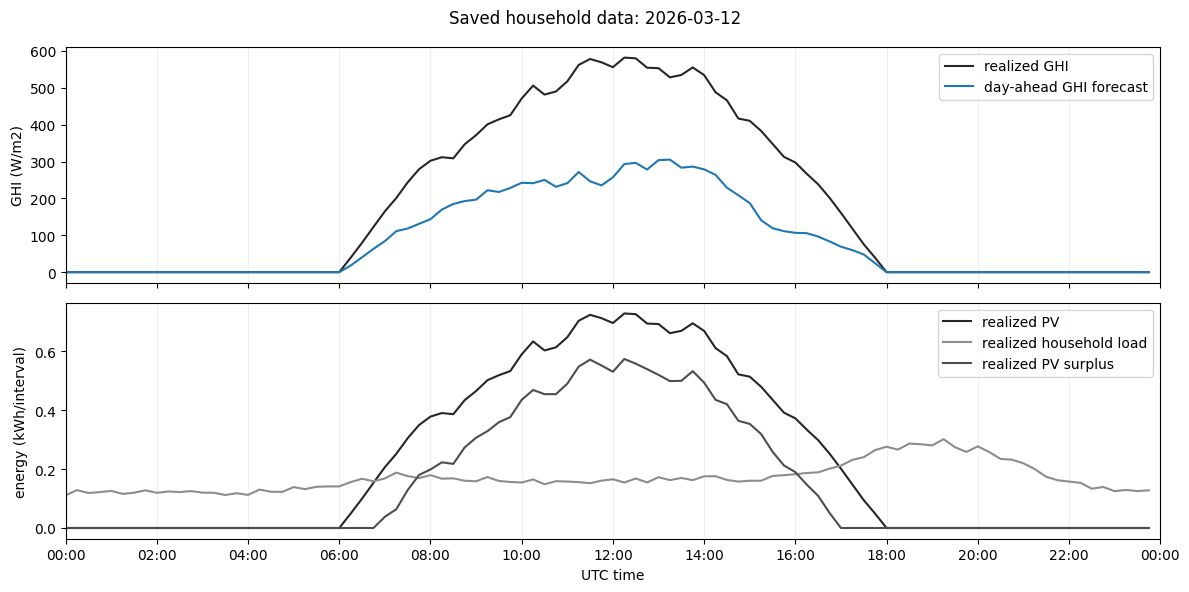

In [6]:
browser_day_data = browse_saved_day(BROWSER_DAY, household_data)




## 4. Select an evaluation day

The table is retrospective. Change `SELECTED_DAY` in section 1, then rerun
this section and the sections below it.




In [13]:
SELECTED_DAY='2026-03-08'
day_start, selected_household, selected_ev = selected_day_data(SELECTED_DAY, household_data, ev_data)




## 5. Run the selected-day Chronos-2 forecast




Chronos-2 forecast accuracy (kWh per 15-minute interval):
 mae_kwh  rmse_kwh
   0.141      0.25


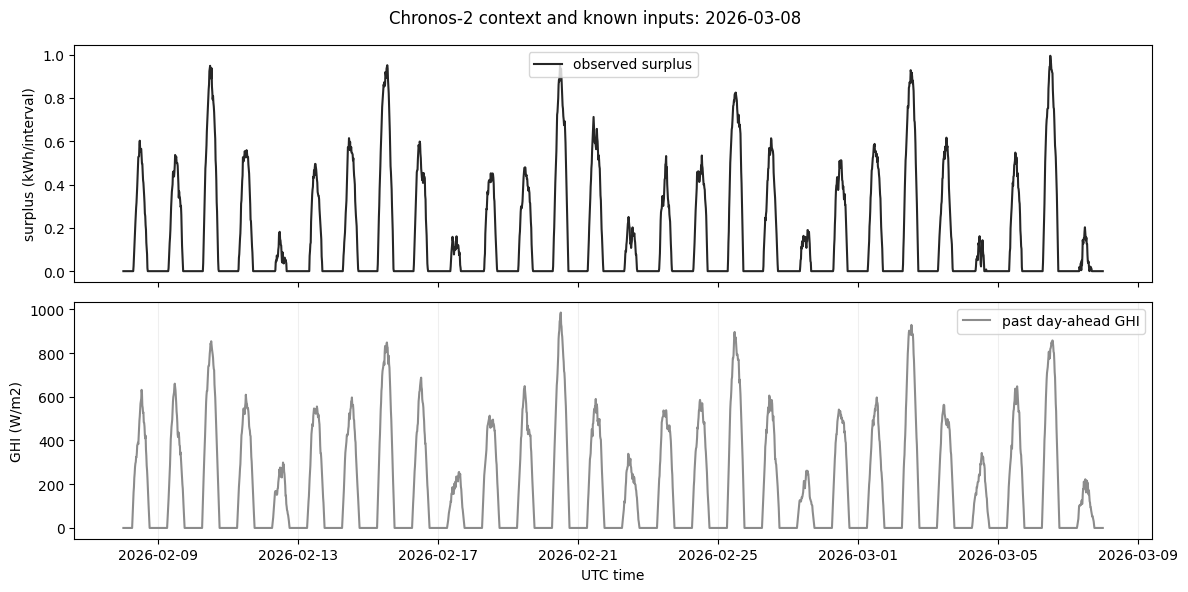

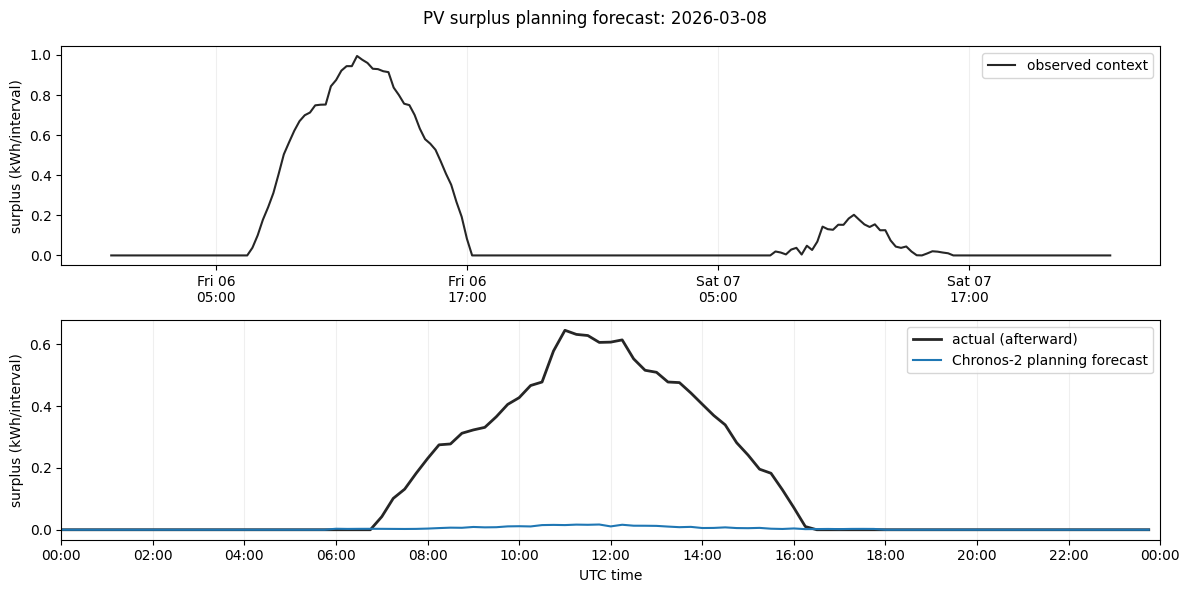

In [14]:
selected_day_forecast = evaluate_single_day_forecast(day_start, fc_base_data)




## 6. Optional: evaluate all 30 days

Set `RUN_30_DAY_EVALUATION` to `True` after trying individual days. It returns
aggregate accuracy metrics for Chronos-2 and the simple baselines.



In [15]:
all_forecasts, forecast_summary = evaluate_all_forecasts(fc_base_data)
print(forecast_summary.round(3))




         method  days  mae_kwh  rmse_kwh
0     chronos_2    30    0.072     0.179
1  previous_day    30    0.095     0.207
2          mean    30    0.126     0.226


## 7. What to take away

- Build each forecast from information available at its planning time.
- Timestamps provide useful daily and weekly patterns without exposing outcomes.
- Compare Chronos-2 with simple baselines over many days, not one result.
- Forecast accuracy and charging cost are related, but neither guarantees the other.
